# BMI Prediction from Face Images — face2bmi 67k
### Models: EfficientNet-B3 | ViT-B/16 | ConvNeXt-Base
Train one model per session. Checkpoints saved every epoch.

In [ ]:
# ============================================================
# CELL 1 — FIX ENVIRONMENT (run once, then restart kernel)
# ============================================================
import subprocess, sys

# Fix Pillow + numpy conflict
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'Pillow==9.5.0', '--quiet', '--force-reinstall'])
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'numpy<2', '--quiet'])
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'timm', '--quiet'])
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'albumentations', '--quiet'])
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'optuna', '--quiet'])
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'pyyaml', '--quiet'])

print('All packages installed.')
print('NOW: Kernel -> Restart -> then run from Cell 2 onwards')
print('Do NOT rerun Cell 1 after restart')

In [1]:
# ============================================================
# CELL 2 — GPU CHECK
# ============================================================
import torch
import PIL

print(f'Pillow version : {PIL.__version__}')  # must be 9.5.0
print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available : {torch.cuda.is_available()}')

if torch.cuda.is_available():
    print(f'GPU name       : {torch.cuda.get_device_name(0)}')
    print(f'GPU memory     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device         : {device}')

# Verify GPU works with a simple tensor op
if torch.cuda.is_available():
    x = torch.randn(3, 3).to(device)
    y = x @ x.T
    print(f'GPU tensor test: OK — shape {y.shape}')

Pillow version : 9.5.0
PyTorch version: 2.10.0+cu128
CUDA available : True
GPU name       : Tesla T4
GPU memory     : 15.6 GB
Device         : cuda
GPU tensor test: OK — shape torch.Size([3, 3])


In [2]:
# ============================================================
# CELL 3 — ALL IMPORTS
# ============================================================
import os, sys, cv2, json, time, yaml, shutil, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.metrics import (mean_absolute_error,
                              mean_squared_error, r2_score)
import joblib
import optuna
import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch
import torch.nn as nn
from torch.utils.data import (Dataset, DataLoader,
                               WeightedRandomSampler)
from torch.cuda.amp import autocast, GradScaler

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sys.path.append('/kaggle/working')

print(f'timm    : {timm.__version__}')
print(f'torch   : {torch.__version__}')
print(f'imports : OK')

timm    : 1.0.26
torch   : 2.10.0+cu128
imports : OK


In [3]:
# ============================================================
# CELL 4 — DIRECTORIES
# ============================================================
BASE    = '/kaggle/working'
UTILS   = f'{BASE}/utils'
CONFIGS = f'{BASE}/configs'
MODELS  = f'{BASE}/saved_models'
RESULTS = f'{BASE}/results/plots'
METRICS = f'{BASE}/results/metrics'
PREDS   = f'{BASE}/results/predictions'

for folder in [UTILS, CONFIGS, MODELS, RESULTS, METRICS, PREDS]:
    os.makedirs(folder, exist_ok=True)

print('Directories created:')
for folder in [UTILS, CONFIGS, MODELS, RESULTS, METRICS, PREDS]:
    print(f'  {folder}')

Directories created:
  /kaggle/working/utils
  /kaggle/working/configs
  /kaggle/working/saved_models
  /kaggle/working/results/plots
  /kaggle/working/results/metrics
  /kaggle/working/results/predictions


In [4]:
# ============================================================
# CELL 5 — WRITE utils/train.py
# ============================================================
train_py = '''
import torch
import torch.nn as nn
import numpy as np
from torch.cuda.amp import autocast, GradScaler


def mixup_data(images, labels, alpha=0.2):
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    batch_size = images.size(0)
    # Keep permutation on CPU to avoid CUDA kernel issues
    index = torch.randperm(batch_size)
    mixed_images = lam * images + (1 - lam) * images[index]
    mixed_labels = lam * labels + (1 - lam) * labels[index]
    return mixed_images, mixed_labels


class SAM(torch.optim.Optimizer):
    def __init__(self, params, base_optimizer, rho=0.05, **kwargs):
        defaults = dict(rho=rho, **kwargs)
        super(SAM, self).__init__(params, defaults)
        self.base_optimizer = base_optimizer(self.param_groups, **kwargs)
        self.param_groups   = self.base_optimizer.param_groups

    @torch.no_grad()
    def first_step(self, zero_grad=False):
        grad_norm = self._grad_norm()
        for group in self.param_groups:
            scale = group["rho"] / (grad_norm + 1e-12)
            for p in group["params"]:
                if p.grad is None:
                    continue
                e_w = p.grad.clone() * scale
                p.add_(e_w)
                self.state[p]["e_w"] = e_w
        if zero_grad:
            self.zero_grad()

    @torch.no_grad()
    def second_step(self, zero_grad=False):
        for group in self.param_groups:
            for p in group["params"]:
                if p.grad is None:
                    continue
                p.sub_(self.state[p]["e_w"])
        self.base_optimizer.step()
        if zero_grad:
            self.zero_grad()

    def _grad_norm(self):
        shared_device = self.param_groups[0]["params"][0].device
        norm = torch.norm(torch.stack([
            p.grad.norm(p=2).to(shared_device)
            for group in self.param_groups
            for p in group["params"]
            if p.grad is not None
        ]), p=2)
        return norm

    def step(self, closure=None):
        pass


class EarlyStopping:
    def __init__(self, patience=5, delta=1e-4):
        self.patience   = patience
        self.delta      = delta
        self.best_score = None
        self.counter    = 0
        self.stop       = False

    def __call__(self, val_mae):
        score = -val_mae
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_score = score
            self.counter    = 0


def train_one_epoch(model, loader, criterion, optimizer,
                    scaler, device, ema=None,
                    use_sam=True, use_mixup=True):
    model.train()
    total_loss, preds_all, labels_all = 0, [], []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if use_mixup:
            images, labels = mixup_data(images, labels, alpha=0.2)

        if use_sam:
            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.first_step(zero_grad=True)

            outputs = model(images)
            loss    = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.second_step(zero_grad=True)
        else:
            optimizer.zero_grad()
            with autocast():
                outputs = model(images)
                loss    = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

        if ema:
            ema.update(model)

        total_loss += loss.item() * images.size(0)
        preds_all.extend(outputs.detach().cpu().numpy())
        labels_all.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    mae      = np.mean(np.abs(np.array(labels_all) -
                               np.array(preds_all)))
    return avg_loss, mae


def validate(model, loader, criterion, device):
    model.eval()
    total_loss, preds_all, labels_all = 0, [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            with autocast():
                outputs = model(images)
                loss    = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            preds_all.extend(outputs.cpu().numpy())
            labels_all.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    mae      = np.mean(np.abs(np.array(labels_all) -
                               np.array(preds_all)))
    return avg_loss, mae, np.array(preds_all), np.array(labels_all)
'''
with open(f'{UTILS}/train.py', 'w') as f:
    f.write(train_py)
print('train.py written')

train.py written


In [5]:
# ============================================================
# CELL 6 — WRITE utils/models.py
# ============================================================
models_py = '''
import torch
import torch.nn as nn
import timm
import copy


class BMIModel(nn.Module):
    def __init__(self, arch, dropout=0.3, pretrained=True):
        super(BMIModel, self).__init__()
        self.backbone = timm.create_model(
            arch, pretrained=pretrained, num_classes=0
        )
        in_features = self.backbone.num_features
        self.head = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, 1)
        )

    def freeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = False

    def unfreeze_backbone(self):
        for param in self.backbone.parameters():
            param.requires_grad = True

    def forward(self, x):
        features = self.backbone(x)
        return self.head(features).squeeze(1)


def get_model(arch, dropout=0.3, pretrained=True):
    return BMIModel(arch, dropout, pretrained)


class ModelEMA:
    def __init__(self, model, decay=0.995):
        self.ema   = copy.deepcopy(model)
        self.decay = decay
        self.ema.eval()

    def update(self, model):
        with torch.no_grad():
            for ema_p, p in zip(self.ema.parameters(),
                                model.parameters()):
                ema_p.data.mul_(self.decay).add_(
                    p.data, alpha=1 - self.decay
                )

    def __call__(self, x):
        return self.ema(x)
'''
with open(f'{UTILS}/models.py', 'w') as f:
    f.write(models_py)
print('models.py written')

models.py written


In [6]:
# ============================================================
# CELL 7 — WRITE utils/dataset.py
# ============================================================
dataset_py = '''
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, WeightedRandomSampler
import albumentations as A
from albumentations.pytorch import ToTensorV2


def get_transforms(img_size=224, mode="train"):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    if mode == "train":
        return A.Compose([
            A.Resize(img_size, img_size),
            A.HorizontalFlip(p=0.5),
            A.RandomBrightnessContrast(p=0.3),
            A.HueSaturationValue(p=0.2),
            A.ShiftScaleRotate(shift_limit=0.03,
                               scale_limit=0.05,
                               rotate_limit=5, p=0.3),
            A.GaussNoise(p=0.15),
            A.Normalize(mean=mean, std=std),
            ToTensorV2()
        ])
    else:
        return A.Compose([
            A.Resize(img_size, img_size),
            A.Normalize(mean=mean, std=std),
            ToTensorV2()
        ])


def get_tta_transforms(img_size=224):
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]
    return [
        A.Compose([A.Resize(img_size, img_size),
                   A.Normalize(mean=mean, std=std),
                   ToTensorV2()]),
        A.Compose([A.Resize(img_size, img_size),
                   A.HorizontalFlip(p=1.0),
                   A.Normalize(mean=mean, std=std),
                   ToTensorV2()]),
        A.Compose([A.Resize(img_size, img_size),
                   A.RandomBrightnessContrast(
                       brightness_limit=0.1,
                       contrast_limit=0.1, p=1.0),
                   A.Normalize(mean=mean, std=std),
                   ToTensorV2()]),
    ]


class BMIDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.loc[idx]
        img_path = f"{self.img_dir}/{row[\'id\']}.png"
        img = cv2.imread(img_path)
        if img is None:
            img = np.zeros((224, 224, 3), dtype=np.uint8)
        else:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        bmi = torch.tensor(float(row[\'bmi\']),
                           dtype=torch.float32)
        if self.transform:
            img = self.transform(image=img)["image"]
        return img, bmi


def get_sampler(dataframe):
    """Oversample extreme BMI + female samples."""
    bmi    = dataframe["bmi"].values
    bins   = [0, 18.5, 25, 30, 35, 100]
    labels = np.digitize(bmi, bins) - 1
    labels = np.clip(labels, 0, len(bins) - 2)

    # Base weights from BMI range
    class_counts   = np.bincount(labels, minlength=len(bins)-1)
    class_weights  = 1.0 / (class_counts + 1e-6)
    sample_weights = class_weights[labels].copy()

    # Extra boost for female samples (6% of dataset)
    if "sex" in dataframe.columns:
        female_mask = (dataframe["sex"].str.lower() == "female").values
        sample_weights[female_mask] *= 3.0

    return WeightedRandomSampler(
        weights     = torch.tensor(sample_weights,
                                   dtype=torch.float32),
        num_samples = len(dataframe),
        replacement = True
    )
'''
with open(f'{UTILS}/dataset.py', 'w') as f:
    f.write(dataset_py)
print('dataset.py written')

dataset.py written


In [7]:
# ============================================================
# OVERWRITE utils/evaluate.py
# ============================================================

evaluate_py = r'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.cuda.amp import autocast
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from scipy.stats import pearsonr


def compute_metrics(labels, preds, model_name="Model"):
    labels = np.array(labels)
    preds = np.array(preds)

    mae = mean_absolute_error(labels, preds)
    mse = mean_squared_error(labels, preds)
    rmse = np.sqrt(mse)
    r2 = r2_score(labels, preds)

    mape = np.mean(
        np.abs((labels - preds) / (labels + 1e-6))
    ) * 100

    pearson = pearsonr(labels, preds)[0]
    bias = np.mean(preds - labels)

    extreme_mask = (labels < 18.5) | (labels > 35)

    if extreme_mask.sum() > 0:
        extreme_mae = mean_absolute_error(
            labels[extreme_mask],
            preds[extreme_mask]
        )
    else:
        extreme_mae = float("nan")

    return {
        "Model": model_name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2": round(r2, 4),
        "MAPE%": round(mape, 2),
        "Pearson": round(pearson, 4),
        "Bias": round(bias, 4),
        "Extreme_MAE": round(extreme_mae, 4)
    }


def predict_tta(
    model,
    dataset,
    tta_transforms,
    device,
    batch_size=64
):
    all_preds = []

    for transform in tta_transforms:
        dataset.transform = transform

        loader = torch.utils.data.DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=False,
            num_workers=2
        )

        preds = []

        model.eval()

        with torch.no_grad():
            for images, _ in loader:
                images = images.to(device)

                with autocast():
                    outputs = model(images)

                preds.extend(
                    outputs.detach().cpu().numpy()
                )

        all_preds.append(np.array(preds))

    return np.mean(all_preds, axis=0)


def plot_predicted_vs_actual(
    labels,
    preds,
    model_name,
    save_path
):
    fig, ax = plt.subplots(figsize=(7, 6))

    ax.scatter(
        labels,
        preds,
        alpha=0.3,
        s=8,
        color="steelblue"
    )

    mn = min(labels)
    mx = max(labels)

    ax.plot(
        [mn, mx],
        [mn, mx],
        "r--",
        lw=1.5,
        label="Perfect"
    )

    mae = mean_absolute_error(labels, preds)
    r2 = r2_score(labels, preds)

    ax.set_title(
        f"{model_name}\\nMAE={mae:.4f}  R2={r2:.4f}"
    )

    ax.set_xlabel("Actual BMI")
    ax.set_ylabel("Predicted BMI")
    ax.legend()

    plt.tight_layout()
    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight"
    )
    plt.close()


def plot_residuals(
    labels,
    preds,
    model_name,
    save_path
):
    residuals = np.array(labels) - np.array(preds)

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.hist(
        residuals,
        bins=40,
        color="darkorange",
        edgecolor="white",
        alpha=0.85
    )

    ax.axvline(
        0,
        color="red",
        linestyle="--",
        lw=1.5
    )

    ax.set_title(
        f"{model_name} Residuals\\n"
        f"Mean={residuals.mean():.3f}  "
        f"Std={residuals.std():.3f}"
    )

    ax.set_xlabel(
        "Residual (Actual - Predicted)"
    )

    ax.set_ylabel("Count")

    plt.tight_layout()
    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight"
    )
    plt.close()


def plot_bmi_range_errors(
    labels,
    preds,
    model_name,
    save_path
):
    labels = np.array(labels)
    preds = np.array(preds)

    bins = {
        "Underweight(<18.5)": (0, 18.5),
        "Normal(18.5-25)": (18.5, 25),
        "Overweight(25-30)": (25, 30),
        "Obese(30-35)": (30, 35),
        "Extreme(>35)": (35, 100)
    }

    range_maes = []
    range_names = []

    for name, (lo, hi) in bins.items():
        mask = (labels >= lo) & (labels < hi)

        if mask.sum() > 0:
            range_maes.append(
                mean_absolute_error(
                    labels[mask],
                    preds[mask]
                )
            )

            range_names.append(
                f"{name}\\n(n={mask.sum()})"
            )

    fig, ax = plt.subplots(figsize=(10, 5))

    bars = ax.bar(
        range_names,
        range_maes,
        color="steelblue",
        edgecolor="white"
    )

    ax.bar_label(
        bars,
        fmt="%.3f",
        padding=3
    )

    ax.set_title(
        f"{model_name} - MAE by BMI Range"
    )

    ax.set_ylabel("MAE")

    plt.tight_layout()

    plt.savefig(
        save_path,
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()
'''

with open(f"{UTILS}/evaluate.py", "w") as f:
    f.write(evaluate_py)

print("✅ evaluate.py overwritten successfully")

# Verify
with open(f"{UTILS}/evaluate.py", "r") as f:
    print("File length:", len(f.readlines()), "lines")

✅ evaluate.py overwritten successfully
File length: 249 lines


In [8]:
import importlib
import utils.evaluate
importlib.reload(utils.evaluate)

print("evaluate.py loaded successfully")

evaluate.py loaded successfully


In [9]:
# ============================================================
# CELL 9 — WRITE utils/utils.py + utils/model_selection.py
# ============================================================
utils_py = '''
import torch, yaml, json, numpy as np, random, os


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True


def save_model(model, path, config=None):
    torch.save(model.state_dict(), path)
    if config:
        cfg_path = path.replace(".pth", "_config.yaml")
        with open(cfg_path, "w") as f:
            yaml.dump(config, f)
    print(f"Model saved: {path}")


def load_model(model, path, device):
    model.load_state_dict(
        torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    return model


def save_results(results_list, path):
    import pandas as pd
    pd.DataFrame(results_list).to_csv(path, index=False)
    print(f"Results saved: {path}")


def save_json(obj, path):
    with open(path, "w") as f:
        json.dump(obj, f, indent=2)
    print(f"JSON saved: {path}")
'''
with open(f'{UTILS}/utils.py', 'w') as f:
    f.write(utils_py)
print('utils.py written')

model_sel_py = '''
import optuna
import numpy as np
from sklearn.metrics import mean_absolute_error


def find_3model_ensemble(preds_dict, true_labels, n_trials=500):
    names = list(preds_dict.keys())
    preds = [preds_dict[n] for n in names]

    def objective(trial):
        w     = [trial.suggest_float(f"w{i}", 0.0, 1.0)
                 for i in range(len(names))]
        w_sum = sum(w) + 1e-9
        w_norm = [wi / w_sum for wi in w]
        ensemble = sum(wn * p
                       for wn, p in zip(w_norm, preds))
        return mean_absolute_error(true_labels, ensemble)

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=n_trials,
                   show_progress_bar=True)
    raw_w  = [study.best_params[f"w{i}"]
              for i in range(len(names))]
    w_sum  = sum(raw_w) + 1e-9
    w_norm = [w / w_sum for w in raw_w]
    return dict(zip(names, w_norm)), study.best_value
'''
with open(f'{UTILS}/model_selection.py', 'w') as f:
    f.write(model_sel_py)
print('model_selection.py written')

# Verify all files
print('\nAll utils files:')
for f in os.listdir(UTILS):
    print(f'  {f}')

utils.py written
model_selection.py written

All utils files:
  __pycache__
  model_selection.py
  dataset.py
  models.py
  train.py
  evaluate.py
  utils.py


In [10]:
# ============================================================
# CELL 10 — WRITE CONFIGS
# ============================================================
train_config = {
    'training': {
        'epochs': 30,
        'batch_size': 64,
        'lr_head': 1e-3,
        'lr_backbone': 1e-4,
        'weight_decay': 1e-4,
        'patience': 5,
        'freeze_epochs': 8,
        'num_workers': 2,
        'seed': 42
    },
    'loss': {'type': 'huber', 'delta': 1.0},
    'scheduler': {
        'type': 'cosine_warm_restarts',
        'T_0': 10, 'T_mult': 2
    }
}

with open(f'{CONFIGS}/train_config_67k.yaml', 'w') as f:
    yaml.dump(train_config, f)

print('Configs written')
print(yaml.dump(train_config))

Configs written
loss:
  delta: 1.0
  type: huber
scheduler:
  T_0: 10
  T_mult: 2
  type: cosine_warm_restarts
training:
  batch_size: 64
  epochs: 30
  freeze_epochs: 8
  lr_backbone: 0.0001
  lr_head: 0.001
  num_workers: 2
  patience: 5
  seed: 42
  weight_decay: 0.0001



In [11]:
# ============================================================
# CELL 11 — LOAD ALL UTILS
# ============================================================
import importlib
import utils.train, utils.models, utils.dataset
import utils.evaluate, utils.model_selection, utils.utils
for mod in [utils.train, utils.models, utils.dataset,
            utils.evaluate, utils.model_selection, utils.utils]:
    importlib.reload(mod)

from utils.train          import SAM, EarlyStopping, train_one_epoch, validate
from utils.models         import get_model, ModelEMA
from utils.dataset        import (BMIDataset, get_transforms,
                                   get_tta_transforms, get_sampler)
from utils.evaluate       import (compute_metrics, predict_tta,
                                   plot_predicted_vs_actual,
                                   plot_residuals,
                                   plot_bmi_range_errors)
from utils.model_selection import find_3model_ensemble
from utils.utils           import (save_model, load_model,
                                    save_results, save_json,
                                    set_seed)
set_seed(42)
print('All utils loaded')

All utils loaded


In [12]:
# ============================================================
# CELL 12 — LOAD CONFIGS
# ============================================================
with open(f'{CONFIGS}/train_config_67k.yaml', 'r') as f:
    train_cfg = yaml.safe_load(f)

EPOCHS        = int(train_cfg['training']['epochs'])
BATCH_SIZE    = int(train_cfg['training']['batch_size'])
LR_HEAD       = float(train_cfg['training']['lr_head'])
LR_BACKBONE   = float(train_cfg['training']['lr_backbone'])
WEIGHT_DECAY  = float(train_cfg['training']['weight_decay'])
PATIENCE      = int(train_cfg['training']['patience'])
FREEZE_EPOCHS = int(train_cfg['training']['freeze_epochs'])
NUM_WORKERS   = int(train_cfg['training']['num_workers'])
HUBER_DELTA   = float(train_cfg['loss']['delta'])

print('Configs loaded:')
print(f'  Epochs        : {EPOCHS}       ({type(EPOCHS).__name__})')
print(f'  Batch size    : {BATCH_SIZE}      ({type(BATCH_SIZE).__name__})')
print(f'  LR head       : {LR_HEAD}    ({type(LR_HEAD).__name__})')
print(f'  LR backbone   : {LR_BACKBONE}   ({type(LR_BACKBONE).__name__})')
print(f'  Freeze epochs : {FREEZE_EPOCHS}       ({type(FREEZE_EPOCHS).__name__})')
print(f'  Patience      : {PATIENCE}       ({type(PATIENCE).__name__})')

Configs loaded:
  Epochs        : 30       (int)
  Batch size    : 64      (int)
  LR head       : 0.001    (float)
  LR backbone   : 0.0001   (float)
  Freeze epochs : 8       (int)
  Patience      : 5       (int)


In [13]:
# ============================================================
# CELL 13 — DATASET PATHS + LOAD CSV
# ============================================================
IMG_DIR  = '/kaggle/input/datasets/rudreshveerkhare/face2bmi-alignedimgs/dataset'
CSV_PATH = '/kaggle/input/datasets/rudreshveerkhare/face2bmi-alignedimgs/final.csv'

print(f'IMG_DIR  exists : {os.path.exists(IMG_DIR)}')
print(f'CSV_PATH exists : {os.path.exists(CSV_PATH)}')

df = pd.read_csv(CSV_PATH)
df = df.rename(columns={'BMI': 'bmi'})

print(f'\nShape   : {df.shape}')
print(f'Columns : {df.columns.tolist()}')
print(f'\nFirst 3 rows:')
print(df.head(3))
print(f'\nBMI stats:')
print(df['bmi'].describe())

# Gender distribution
print(f'\nGender distribution:')
print(df['sex'].value_counts())
print(f'Female %: {(df["sex"]=="Female").mean()*100:.1f}%')

IMG_DIR  exists : True
CSV_PATH exists : True

Shape   : (59870, 4)
Columns : ['id', 'sex', 'age', 'bmi']

First 3 rows:
       id   sex  age        bmi
0  M10909  Male   33  24.679446
1  M16885  Male   38  21.614441
2  B83719  Male   35  22.494637

BMI stats:
count    59870.000000
mean        27.889196
std          5.201188
min          2.828468
25%         24.323786
50%         27.120270
75%         30.661595
max         78.297773
Name: bmi, dtype: float64

Gender distribution:
sex
Male      56221
Female     3649
Name: count, dtype: int64
Female %: 6.1%


In [14]:
# ============================================================
# CELL 14 — VALIDATE IMAGES + CLEAN DATASET
# ============================================================
all_imgs   = os.listdir(IMG_DIR)
img_names  = set(f.replace('.png', '') for f in all_imgs
                 if f.endswith('.png'))
csv_ids    = set(df['id'].astype(str).values)
missing    = csv_ids - img_names

print(f'Total images on disk : {len(img_names)}')
print(f'IDs in CSV           : {len(csv_ids)}')
print(f'Missing on disk      : {len(missing)}')

df['img_exists'] = df['id'].astype(str).isin(img_names)
clean_df = df[df['img_exists']].copy().reset_index(drop=True)

# Keep sex column for weighted sampler
clean_df = clean_df[['id', 'bmi', 'sex']].copy()
print(f'\nClean dataset : {len(clean_df)} samples')
print(f'Female samples: {(clean_df["sex"]=="Female").sum()}')
print(f'Male samples  : {(clean_df["sex"]=="Male").sum()}')

Total images on disk : 66976
IDs in CSV           : 59870
Missing on disk      : 20

Clean dataset : 59850 samples
Female samples: 3649
Male samples  : 56201


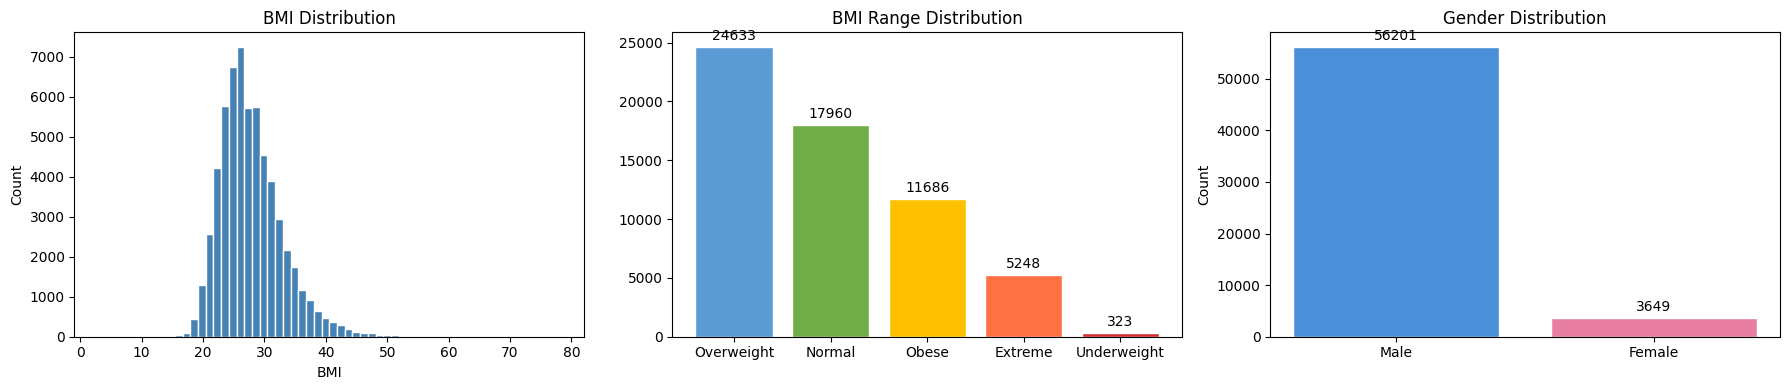


BMI Range Counts:
  Overweight     : 24633  (41.2%)
  Normal         : 17960  (30.0%)
  Obese          : 11686  (19.5%)
  Extreme        :  5248  (8.8%)
  Underweight    :   323  (0.5%)


In [15]:
# ============================================================
# CELL 15 — EDA
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(clean_df['bmi'], bins=60,
             color='steelblue', edgecolor='white')
axes[0].set_title('BMI Distribution')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Count')

bins_r  = [0, 18.5, 25, 30, 35, 100]
labs_r  = ['Underweight','Normal','Overweight','Obese','Extreme']
counts  = pd.cut(clean_df['bmi'], bins=bins_r,
                 labels=labs_r).value_counts()
colors  = ['#5B9BD5','#70AD47','#FFC000','#FF7043','#D32F2F']
bars    = axes[1].bar(counts.index, counts.values,
                       color=colors, edgecolor='white')
axes[1].bar_label(bars, padding=3)
axes[1].set_title('BMI Range Distribution')

gender  = clean_df['sex'].value_counts()
axes[2].bar(gender.index, gender.values,
            color=['#4A90D9','#E87EA1'], edgecolor='white')
axes[2].bar_label(axes[2].containers[0], padding=3)
axes[2].set_title('Gender Distribution')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig(f'{RESULTS}/eda_67k.png', dpi=150,
            bbox_inches='tight')
plt.show()

print('\nBMI Range Counts:')
for label, count in counts.items():
    pct = count / len(clean_df) * 100
    print(f'  {label:<15}: {count:>5}  ({pct:.1f}%)')

In [16]:
# ============================================================
# CELL 16 — GENDER-STRATIFIED SPLIT
# ============================================================
# Separate male and female
male_df   = clean_df[clean_df['sex'] == 'Male'].reset_index(drop=True)
female_df = clean_df[clean_df['sex'] == 'Female'].reset_index(drop=True)

print(f'Male   : {len(male_df)}')
print(f'Female : {len(female_df)}')

# Split each gender 80/20
m_train, m_test = train_test_split(
    male_df, test_size=0.2, random_state=42)
f_train, f_test = train_test_split(
    female_df, test_size=0.2, random_state=42)

# Combine
train_df = pd.concat([m_train, f_train]).reset_index(drop=True)
test_df  = pd.concat([m_test,  f_test]).reset_index(drop=True)

# Shuffle
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df  = test_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Verify
overlap = set(train_df['id']) & set(test_df['id'])
print(f'\nTrain : {len(train_df)} samples')
print(f'Test  : {len(test_df)}  samples')
print(f'Overlap (must be 0) : {len(overlap)}')
print(f'\nTrain BMI : {train_df["bmi"].mean():.2f} +/- {train_df["bmi"].std():.2f}')
print(f'Test  BMI : {test_df["bmi"].mean():.2f} +/- {test_df["bmi"].std():.2f}')
print(f'\nTrain female% : {(train_df["sex"]=="Female").mean()*100:.1f}%')
print(f'Test  female% : {(test_df["sex"]=="Female").mean()*100:.1f}%')

train_df.to_csv(f'{METRICS}/train_df_67k.csv', index=False)
test_df.to_csv(f'{METRICS}/test_df_67k.csv',   index=False)
print('\nSplits saved')

Male   : 56201
Female : 3649

Train : 47879 samples
Test  : 11971  samples
Overlap (must be 0) : 0

Train BMI : 27.89 +/- 5.21
Test  BMI : 27.87 +/- 5.17

Train female% : 6.1%
Test  female% : 6.1%

Splits saved


In [17]:
# ============================================================
# CELL 17 — BUILD DATALOADERS + SANITY CHECK
# ============================================================
train_transform = get_transforms(224, mode='train')
val_transform   = get_transforms(224, mode='val')

train_dataset   = BMIDataset(train_df, IMG_DIR, train_transform)
test_dataset    = BMIDataset(test_df,  IMG_DIR, val_transform)

# Sampler handles BMI imbalance + female oversampling
sampler      = get_sampler(train_df)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          sampler=sampler,
                          num_workers=NUM_WORKERS,
                          pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE,
                          shuffle=False,
                          num_workers=NUM_WORKERS,
                          pin_memory=True)

print(f'Train samples : {len(train_dataset)}')
print(f'Test  samples : {len(test_dataset)}')
print(f'Train batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')

# Sanity check
images, labels = next(iter(train_loader))
print(f'\nImage shape   : {images.shape}')
print(f'Label shape   : {labels.shape}')
print(f'Sample BMIs   : {labels[:5].tolist()}')
print(f'Pixel range   : [{images.min():.2f}, {images.max():.2f}]')
print('\nDataLoaders ready')

Train samples : 47879
Test  samples : 11971
Train batches : 749
Test  batches : 188

Image shape   : torch.Size([64, 3, 224, 224])
Label shape   : torch.Size([64])
Sample BMIs   : [39.573509216308594, 24.263954162597656, 15.946104049682617, 25.493921279907227, 44.62336349487305]
Pixel range   : [-2.12, 2.64]

DataLoaders ready


In [20]:
# ============================================================
# CELL 18 — MASTER TRAINING FUNCTION (fixed weights_only)
# ============================================================
def train_model_67k(model_name, arch, dropout=0.3):
    print(f"\n{'='*60}")
    print(f"  Training : {model_name}")
    print(f"  Arch     : {arch}")
    print(f"  Dropout  : {dropout}")
    print(f"{'='*60}")

    safe      = model_name.lower().replace(
                 ' ', '_').replace('-', '_').replace('/', '_')
    ckpt_path  = f'{MODELS}/{safe}_checkpoint.pth'
    final_path = f'{MODELS}/{safe}_final.pth'
    ema_path   = f'{MODELS}/{safe}_ema.pth'

    tr_transform  = get_transforms(224, mode='train')
    val_transform = get_transforms(224, mode='val')
    tr_dataset    = BMIDataset(train_df, IMG_DIR, tr_transform)
    te_dataset    = BMIDataset(test_df,  IMG_DIR, val_transform)
    sampler       = get_sampler(train_df)

    tr_loader = DataLoader(tr_dataset, batch_size=BATCH_SIZE,
                           sampler=sampler,
                           num_workers=NUM_WORKERS,
                           pin_memory=True)
    te_loader = DataLoader(te_dataset,  batch_size=BATCH_SIZE,
                           shuffle=False,
                           num_workers=NUM_WORKERS,
                           pin_memory=True)

    model = get_model(arch, dropout=dropout).to(device)
    ema   = ModelEMA(model, decay=0.995)

    criterion = nn.HuberLoss(delta=HUBER_DELTA)
    scaler    = GradScaler()

    start_epoch  = 1
    best_val_mae = float('inf')
    best_weights = None
    history      = {'train_loss': [], 'val_loss': [],
                    'train_mae':  [], 'val_mae':  []}

    if os.path.exists(ckpt_path):
        print(f'\nResuming from checkpoint...')
        # ✅ FIXED — weights_only=False
        ckpt         = torch.load(ckpt_path, map_location=device,
                                  weights_only=False)
        model.load_state_dict(ckpt['model_state'])
        start_epoch  = ckpt['epoch'] + 1
        best_val_mae = ckpt['best_val_mae']
        history      = ckpt.get('history', history)
        print(f'  Resuming epoch  : {start_epoch}')
        print(f'  Best MAE so far : {best_val_mae:.4f}')

    model.freeze_backbone()
    optimizer = SAM(
        [{'params': model.head.parameters()}],
        torch.optim.AdamW,
        lr=LR_HEAD, weight_decay=WEIGHT_DECAY
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer.base_optimizer, T_0=10, T_mult=2
    )
    early_stop = EarlyStopping(patience=PATIENCE)

    print(f'\n--- Phase 1: Head only ({FREEZE_EPOCHS} epochs) ---\n')

    for epoch in range(start_epoch, EPOCHS + 1):

        if epoch == FREEZE_EPOCHS + 1:
            print(f'\n--- Phase 2: Full fine-tune (epoch {epoch}+) ---\n')
            model.unfreeze_backbone()
            optimizer = SAM(
                [
                    {'params': model.backbone.parameters(),
                     'lr': LR_BACKBONE},
                    {'params': model.head.parameters(),
                     'lr': LR_HEAD}
                ],
                torch.optim.AdamW,
                lr=LR_BACKBONE,
                weight_decay=WEIGHT_DECAY
            )
            scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
                optimizer.base_optimizer, T_0=10, T_mult=2
            )

        train_loss, train_mae = train_one_epoch(
            model, tr_loader, criterion,
            optimizer, scaler, device, ema,
            use_sam=True, use_mixup=True
        )
        val_loss, val_mae, _, _ = validate(
            model, te_loader, criterion, device
        )
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_mae'].append(train_mae)
        history['val_mae'].append(val_mae)

        if val_mae < best_val_mae:
            best_val_mae = val_mae
            best_weights = {k: v.clone() for k, v in
                            model.state_dict().items()}
            tag = ' <- best'
        else:
            tag = ''

        print(f'  Epoch {epoch:>3}/{EPOCHS} | '
              f'TrLoss:{train_loss:.4f} | '
              f'TrMAE:{train_mae:.4f} | '
              f'ValLoss:{val_loss:.4f} | '
              f'ValMAE:{val_mae:.4f}{tag}')

        torch.save({
            'epoch':        epoch,
            'model_state':  model.state_dict(),
            'best_val_mae': best_val_mae,
            'history':      history,
        }, ckpt_path)

        early_stop(val_mae)
        if early_stop.stop:
            print(f'\n  Early stopping at epoch {epoch}')
            break

    model.load_state_dict(best_weights)
    save_model(model, final_path, config={
        'arch': arch, 'dropout': dropout,
        'img_size': 224, 'dataset': 'face2bmi_67k'
    })
    save_model(ema.ema, ema_path)

    print('\nRunning TTA predictions...')
    tta_transforms = get_tta_transforms(224)
    tta_preds      = predict_tta(model, te_dataset,
                                  tta_transforms, device,
                                  batch_size=BATCH_SIZE)
    tta_labels     = test_df['bmi'].values

    metrics = compute_metrics(tta_labels, tta_preds, model_name)
    print(f'\n  Final metrics (TTA):')
    for k, v in metrics.items():
        print(f'    {k:<15}: {v}')

    male_mask   = (test_df['sex'] == 'Male').values
    female_mask = (test_df['sex'] == 'Female').values
    if female_mask.sum() > 0:
        m_mae = mean_absolute_error(
            tta_labels[male_mask], tta_preds[male_mask])
        f_mae = mean_absolute_error(
            tta_labels[female_mask], tta_preds[female_mask])
        print(f'\n  Male   MAE : {m_mae:.4f}')
        print(f'  Female MAE : {f_mae:.4f}')

    for fn, suffix in [
        (plot_predicted_vs_actual, 'pred_vs_actual'),
        (plot_residuals,           'residuals'),
        (plot_bmi_range_errors,    'range_errors'),
    ]:
        fn(tta_labels, tta_preds, model_name,
           f'{RESULTS}/{safe}_{suffix}.png')

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'],   label='Val')
    axes[0].set_title(f'{model_name} Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()
    axes[1].plot(history['train_mae'], label='Train')
    axes[1].plot(history['val_mae'],   label='Val')
    axes[1].set_title(f'{model_name} MAE')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()
    plt.tight_layout()
    plt.savefig(f'{RESULTS}/{safe}_curves.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    if os.path.exists(ckpt_path):
        os.remove(ckpt_path)
        print('Checkpoint deleted')

    return metrics, history, tta_preds

print('train_model_67k defined')

train_model_67k defined


In [ ]:
# ============================================================
# CELL 19 — SESSION 1: TRAIN EFFICIENTNET-B3
# Run this session. Download efficientnet_b3_final.pth after.
# ============================================================
results_all = []
preds_all   = {}

metrics_b3, history_b3, preds_b3 = train_model_67k(
    model_name = 'EfficientNet-B3',
    arch       = 'efficientnet_b3',
    dropout    = 0.3
)
results_all.append(metrics_b3)
preds_all['EfficientNet-B3'] = preds_b3

save_results(results_all, f'{METRICS}/results_67k.csv')

print(f"\n{'='*50}")
print(f"  SESSION 1 COMPLETE")
print(f"  MAE : {metrics_b3['MAE']}")
print(f"  R2  : {metrics_b3['R2']}")
print(f"{'='*50}")
print('\nDOWNLOAD NOW: efficientnet_b3_final.pth')
print('Output panel -> saved_models -> download')

In [22]:
import shutil

src = '/kaggle/input/datasets/kishlaytejeswi/bmi-models-67k/vit_b_16_checkpoint.pth'
dst = f'{MODELS}/vit_b_16_checkpoint.pth'

shutil.copy(src, dst)
print(f'Checkpoint copied to: {dst}')

# Fix — add weights_only=False
ckpt = torch.load(dst, map_location=device, weights_only=False)
print(f'Last completed epoch : {ckpt["epoch"]}')
print(f'Best val MAE so far  : {ckpt["best_val_mae"]:.4f}')
print(f'History length       : {len(ckpt["history"]["val_mae"])} epochs')

Checkpoint copied to: /kaggle/working/saved_models/vit_b_16_checkpoint.pth
Last completed epoch : 9
Best val MAE so far  : 3.5458
History length       : 9 epochs


In [ ]:
# ============================================================
# CELL 20 — SESSION 2: TRAIN VIT-B/16
# First rerun Cells 1-18, then run this cell.
# ============================================================
results_all = []
preds_all   = {}

metrics_vit, history_vit, preds_vit = train_model_67k(
    model_name = 'ViT-B-16',
    arch       = 'vit_base_patch16_224',
    dropout    = 0.3
)
results_all.append(metrics_vit)
preds_all['ViT-B-16'] = preds_vit

save_results(results_all, f'{METRICS}/results_67k_vit.csv')

print(f"\n{'='*50}")
print(f"  SESSION 2 COMPLETE")
print(f"  MAE : {metrics_vit['MAE']}")
print(f"  R2  : {metrics_vit['R2']}")
print(f"{'='*50}")
print('\nDOWNLOAD NOW: vit_b_16_final.pth')


  Training : ViT-B-16
  Arch     : vit_base_patch16_224
  Dropout  : 0.3


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]


Resuming from checkpoint...
  Resuming epoch  : 10
  Best MAE so far : 3.5458

--- Phase 1: Head only (8 epochs) ---

  Epoch  10/30 | TrLoss:4.3438 | TrMAE:4.8195 | ValLoss:2.9127 | ValMAE:3.3791 <- best
  Epoch  11/30 | TrLoss:4.1183 | TrMAE:4.5930 | ValLoss:2.9986 | ValMAE:3.4669
  Epoch  12/30 | TrLoss:4.1120 | TrMAE:4.5862 | ValLoss:3.3091 | ValMAE:3.7788
  Epoch  13/30 | TrLoss:4.0346 | TrMAE:4.5081 | ValLoss:3.0396 | ValMAE:3.5086


In [ ]:
# ============================================================
# CELL 21 — SESSION 3: TRAIN CONVNEXT-BASE
# First rerun Cells 1-18, then run this cell.
# ============================================================
results_all = []
preds_all   = {}

metrics_cnx, history_cnx, preds_cnx = train_model_67k(
    model_name = 'ConvNeXt-Base',
    arch       = 'convnext_base',
    dropout    = 0.3
)
results_all.append(metrics_cnx)
preds_all['ConvNeXt-Base'] = preds_cnx

save_results(results_all, f'{METRICS}/results_67k_cnx.csv')

print(f"\n{'='*50}")
print(f"  SESSION 3 COMPLETE")
print(f"  MAE : {metrics_cnx['MAE']}")
print(f"  R2  : {metrics_cnx['R2']}")
print(f"{'='*50}")
print('\nDOWNLOAD NOW: convnext_base_final.pth')

In [ ]:
# ============================================================
# CELL 22 — SESSION 4: ENSEMBLE
# Upload all 3 .pth files to Kaggle dataset 'bmi-models-67k'
# Attach it, then rerun Cells 1-18 + this cell.
# ============================================================
MODELS_67K = '/kaggle/input/bmi-models-67k'

val_transform  = get_transforms(224, mode='val')
te_dataset_ens = BMIDataset(test_df, IMG_DIR, val_transform)
tta_transforms = get_tta_transforms(224)
true_labels    = test_df['bmi'].values

model_specs = [
    ('EfficientNet-B3', 'efficientnet_b3',
     'efficientnet_b3_final.pth'),
    ('ViT-B-16',        'vit_base_patch16_224',
     'vit_b_16_final.pth'),
    ('ConvNeXt-Base',   'convnext_base',
     'convnext_base_final.pth'),
]

results_all = []
preds_all   = {}

for name, arch, fname in model_specs:
    print(f'Loading {name}...')
    model = load_model(
        get_model(arch, dropout=0.3).to(device),
        f'{MODELS_67K}/{fname}', device
    )
    preds   = predict_tta(model, te_dataset_ens,
                           tta_transforms, device,
                           batch_size=64)
    metrics = compute_metrics(true_labels, preds, name)
    results_all.append(metrics)
    preds_all[name] = preds
    print(f'  MAE: {metrics["MAE"]:.4f}  R2: {metrics["R2"]:.4f}')

# 3-model Optuna ensemble
print('\nRunning Optuna ensemble...')
best_weights, best_mae = find_3model_ensemble(
    preds_all, true_labels, n_trials=500
)

print(f'\nBest ensemble weights:')
for name, w in best_weights.items():
    print(f'  {name:<20} : {w:.4f}')
print(f'\nEnsemble MAE : {best_mae:.4f}')

# Final ensemble predictions
ensemble_preds = sum(
    best_weights[n] * preds_all[n]
    for n in best_weights
)
ens_metrics = compute_metrics(
    true_labels, ensemble_preds, '3-Model Ensemble'
)

# Full table
results_all.append(ens_metrics)
results_df = pd.DataFrame(results_all).sort_values(
    'MAE').reset_index(drop=True)
results_df.index += 1

print(f"\n{'='*75}")
print('      face2bmi 67k -- FINAL MODEL COMPARISON')
print(f"{'='*75}")
print(results_df.to_string())
print(f"{'='*75}")

# Gender breakdown for ensemble
male_mask   = (test_df['sex'] == 'Male').values
female_mask = (test_df['sex'] == 'Female').values
print(f'\nEnsemble Male   MAE: {mean_absolute_error(true_labels[male_mask], ensemble_preds[male_mask]):.4f}')
print(f'Ensemble Female MAE: {mean_absolute_error(true_labels[female_mask], ensemble_preds[female_mask]):.4f}')

# Save
results_df.to_csv(f'{METRICS}/final_results_67k.csv', index=True)
save_json(best_weights, f'{METRICS}/ensemble_weights_67k.json')
pd.DataFrame({
    'true_bmi'      : true_labels,
    'ensemble_preds': ensemble_preds,
    **{f'{n}_preds': preds_all[n] for n in preds_all}
}).to_csv(f'{PREDS}/final_predictions_67k.csv', index=False)

plot_predicted_vs_actual(
    true_labels, ensemble_preds,
    '3-Model Ensemble 67k',
    f'{RESULTS}/ensemble_67k_pred_vs_actual.png'
)
plot_bmi_range_errors(
    true_labels, ensemble_preds,
    '3-Model Ensemble 67k',
    f'{RESULTS}/ensemble_67k_range_errors.png'
)
print('\nAll results saved')